In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [22]:
# Univariate Tasks
# loding matches dataset 
ipl_df = pd.read_csv("matches.csv")
ipl_df.head()
ipl_df.info()
ipl_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [23]:
# Insight:
# Dataset contains IPL match-level information including teams, toss decisions,
# match outcomes, and player performance.

In [3]:
# checking missing values
ipl_df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [4]:
#filling missing  from winner with 'no result'
ipl_df["winner"] = ipl_df["winner"].fillna("no result")
#'method ' This column usually indicates if the Duckworth-Lewis (DLS) method was used due to rain. If it's null, it just means it was a normal match.
ipl_df['method'] = ipl_df['method'].fillna('normal')
# we declare citys as 'Unknown'
ipl_df['city']= ipl_df['city'].fillna('unkown')
# we declare missing player of the match as 'no result'
ipl_df['player_of_match']= ipl_df['player_of_match'].fillna('NO result')
# Result Margin, Target Runs, and Overs (3-19 Nulls) These are missing for matches that didn't finish, so we are taking '0'
ipl_df['result_margin'] = ipl_df['result_margin'].fillna(0)
ipl_df['target_runs'] = ipl_df['target_runs'].fillna(0)
ipl_df['target_overs'] = ipl_df['target_overs'].fillna(0)

In [5]:
# Check for team name consistency
print(ipl_df['team1'].unique())

['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Rising Pune Supergiant' 'Delhi Capitals'
 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']


In [6]:
# Standardize Team Names
ipl_df.replace('Royal Challengers Bangalore', 'Royal Challengers Bengaluru', inplace=True)
ipl_df.replace('Rising Pune Supergiant', 'Rising Pune Supergiants', inplace=True)
ipl_df.replace('Kings XI Punjab', 'Punjab Kings', inplace=True)

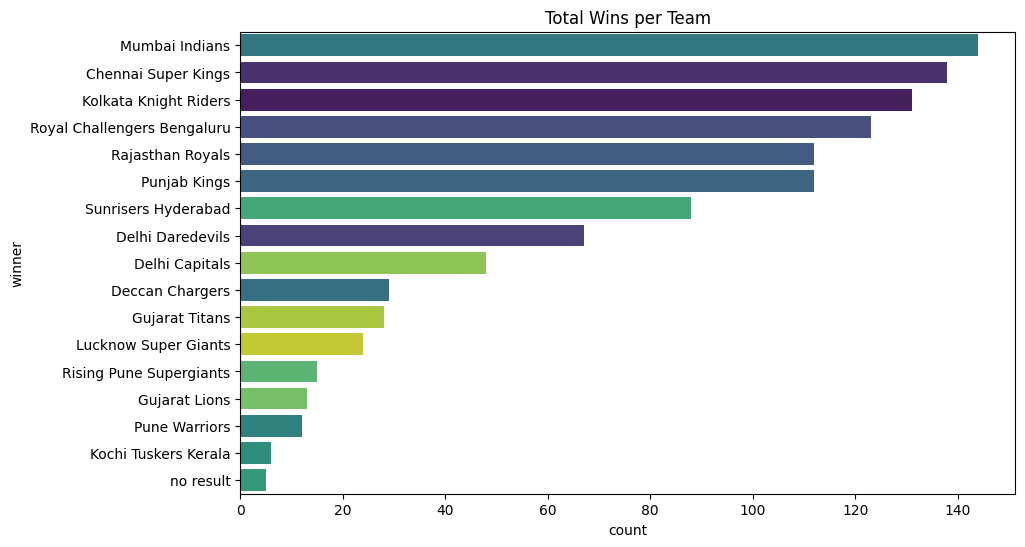

In [7]:
# 1. Distribution of Wins (Categorical)
plt.figure(figsize=(10,6))
# Assign 'winner' to both y and hue, then set legend=False
sns.countplot(
    y='winner', 
    data=ipl_df, 
    order=ipl_df['winner'].value_counts().index, 
    hue='winner', 
    palette='viridis', 
    legend=False
)
plt.title('Total Wins per Team')
plt.show()

In [ ]:
# Insight:
# Teams like Mumbai Indians and Chennai Super Kings dominate in total wins,
# indicating consistent performance and strong team strategies.

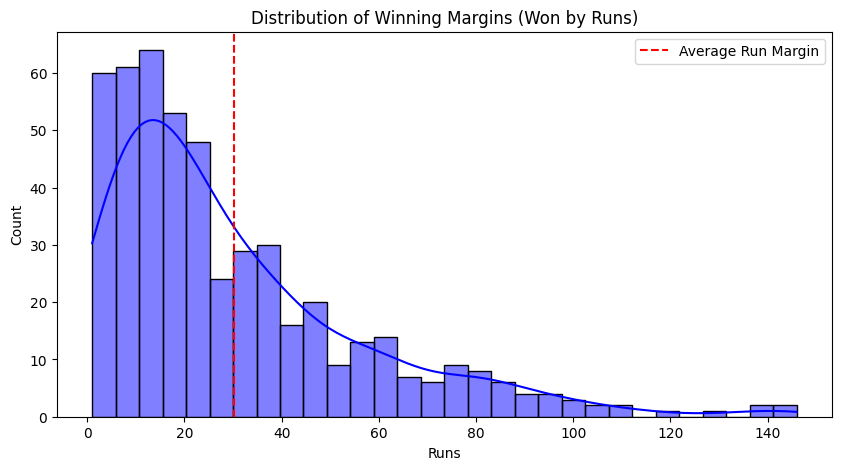

In [8]:
# 1. Filter for matches won by runs
won_by_runs_df = ipl_df[ipl_df['result'] == 'runs']
# 2. Visualization using 'result_margin'
plt.figure(figsize=(10,5))
sns.histplot(won_by_runs_df['result_margin'], bins=30, kde=True, color='blue')
# Add a vertical line for the average winning margin (runs)
plt.axvline(won_by_runs_df['result_margin'].mean(), color='red', linestyle='--', label='Average Run Margin')
plt.title('Distribution of Winning Margins (Won by Runs)')
plt.xlabel('Runs')
plt.legend()
plt.show()

In [ ]:
# Insight:
# High win percentage teams show consistency rather than just high participation,
# indicating strong team balance and strategy.

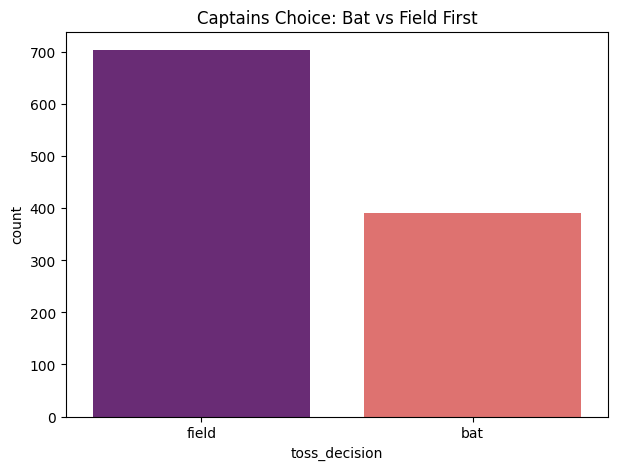

In [9]:
# Simple count of Bat vs Field decisions
plt.figure(figsize=(7,5))
sns.countplot(x='toss_decision', data=ipl_df, hue='toss_decision', palette='magma', legend=False)
plt.title('Captains Choice: Bat vs Field First')
plt.show()

In [ ]:
# Insight:
# Teams prefer fielding first, indicating a strong preference for chasing strategy.

In [28]:
ipl_df.groupby('toss_decision')['winner'].count() # Insight:
# Matches where teams choose to field first tend to result in more wins,
# reinforcing chasing as a successful strategy

toss_decision
bat      390
field    700
Name: winner, dtype: int64

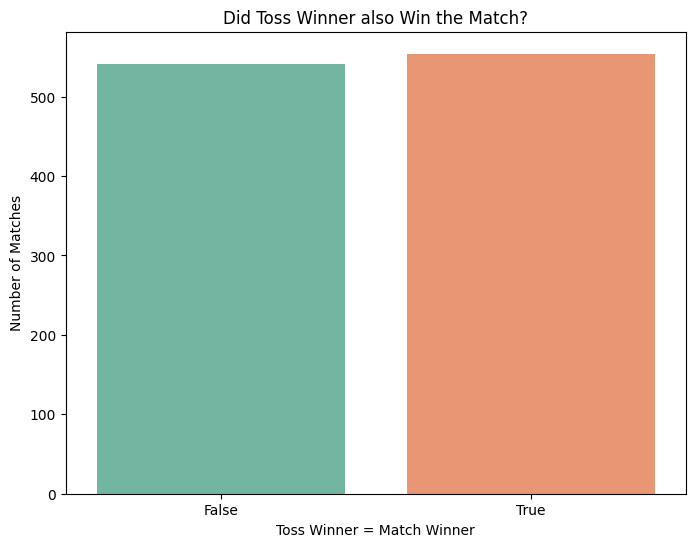

Percentage of matches won by toss winner: 50.59%


In [33]:
# . Bivariate Tasks (The "Connection")
# Create a column to check if toss winner is match winner
ipl_df['toss_win_match_win'] = ipl_df['toss_winner'] == ipl_df['winner']
# Visualization
plt.figure(figsize=(8,6))
sns.countplot(data=ipl_df, x='toss_win_match_win', hue='toss_win_match_win', palette='Set2', legend=False)
plt.title('Did Toss Winner also Win the Match?')
plt.xlabel('Toss Winner = Match Winner')
plt.ylabel('Number of Matches')
plt.show()
# Percentage Insight
win_pct = ipl_df['toss_win_match_win'].value_counts(normalize=True) * 100
print(f"Percentage of matches won by toss winner: {win_pct[True]:.2f}%")

In [36]:
# Insight:
# Toss has limited influence (~50) on match outcome,
# suggesting performance matters more than initial advantag

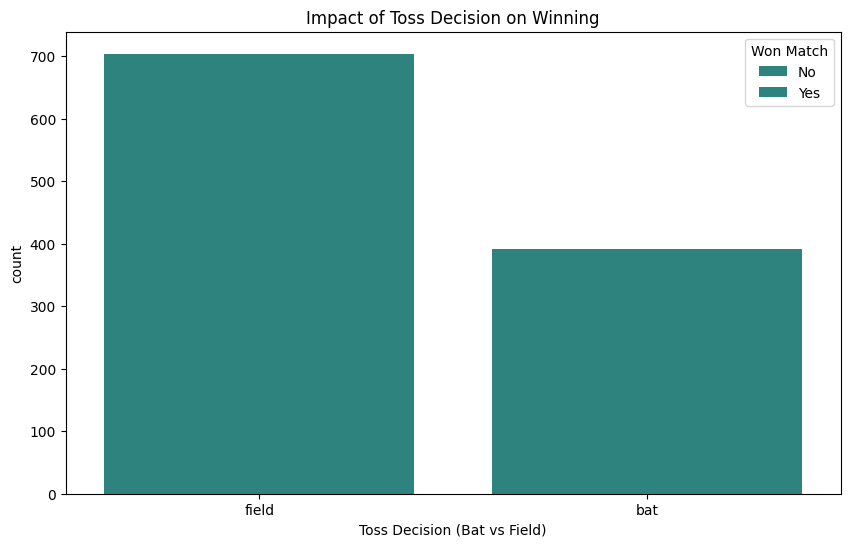

In [11]:
# Bivariate analysis of Toss Decision and Winning
plt.figure(figsize=(10,6))
sns.countplot(data=ipl_df, x='toss_decision', hue='winner' == 'toss_winner', palette='viridis')
plt.title('Impact of Toss Decision on Winning')
plt.xlabel('Toss Decision (Bat vs Field)')
plt.legend(title='Won Match', labels=['No', 'Yes'])
plt.show()

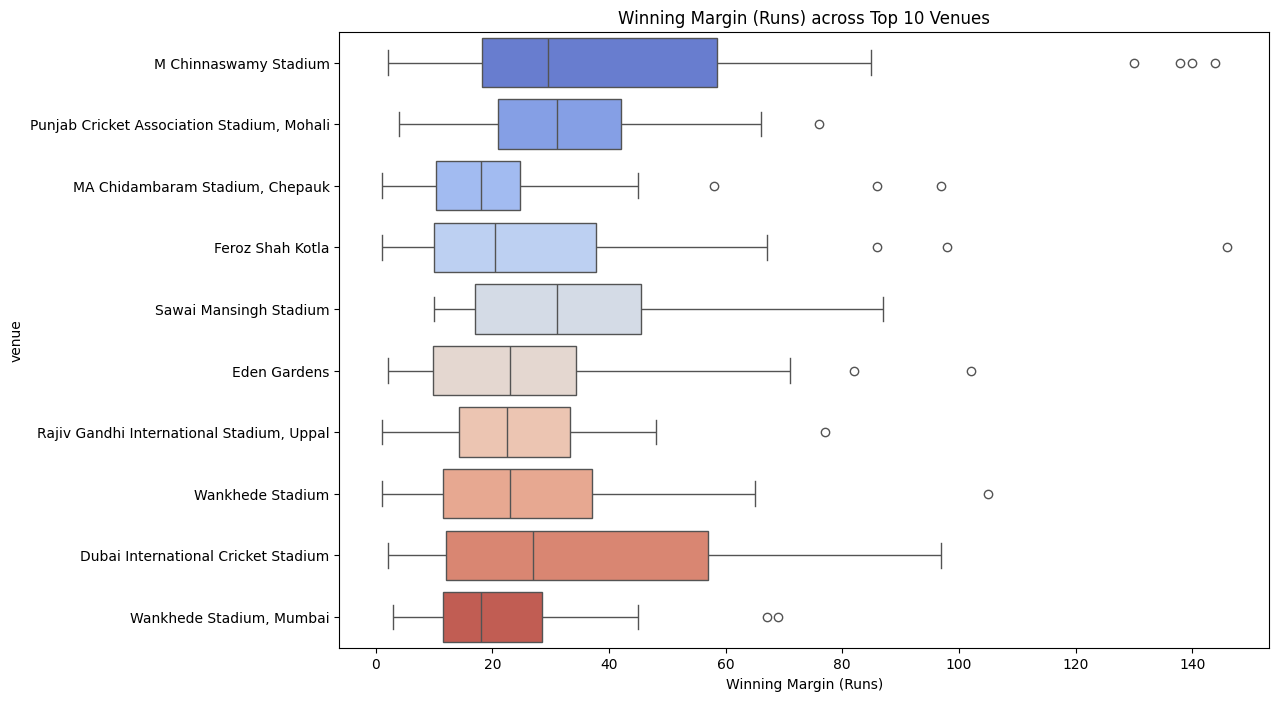

In [17]:
# 1. Filter for matches won by runs (Bivariate: result_margin only makes sense for 'runs')
runs_df = ipl_df[ipl_df['result'] == 'runs']
# 2. Identify the Top 10 Venues by match count
top_venues = ipl_df['venue'].value_counts().nlargest(10).index
filtered_venue_df = runs_df[runs_df['venue'].isin(top_venues)]
# 4. Now perform the Visualization
plt.figure(figsize=(12,8))
sns.boxplot(
    data=filtered_venue_df, 
    x='result_margin', 
    y='venue', 
    hue='venue', 
    palette='coolwarm', 
    legend=False
)
plt.title('Winning Margin (Runs) across Top 10 Venues')
plt.xlabel('Winning Margin (Runs)')
plt.show()

In [35]:
ipl_df.groupby('venue')['winner'].value_counts().head(10) # Insight:
# Teams perform better at certain venues, indicating home advantage and pitch familiarity.

venue                        winner                     
Arun Jaitley Stadium         Delhi Capitals                 4
                             Delhi Daredevils               4
                             Sunrisers Hyderabad            2
                             Chennai Super Kings            1
                             Kings XI Punjab                1
                             Mumbai Indians                 1
                             Royal Challengers Bangalore    1
Arun Jaitley Stadium, Delhi  Delhi Capitals                 6
                             Mumbai Indians                 3
                             Chennai Super Kings            2
Name: count, dtype: int64

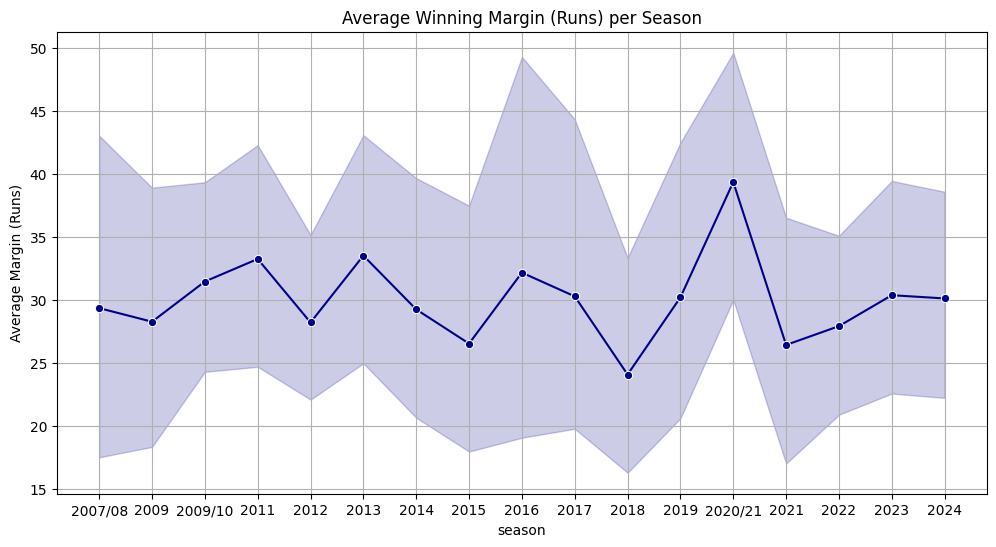

In [14]:
#Season-wise Competitiveness
plt.figure(figsize=(12,6))
sns.lineplot(data=runs_df, x='season', y='result_margin', marker='o', color='darkblue')
plt.title('Average Winning Margin (Runs) per Season')
plt.ylabel('Average Margin (Runs)')
plt.grid(True)
plt.show()

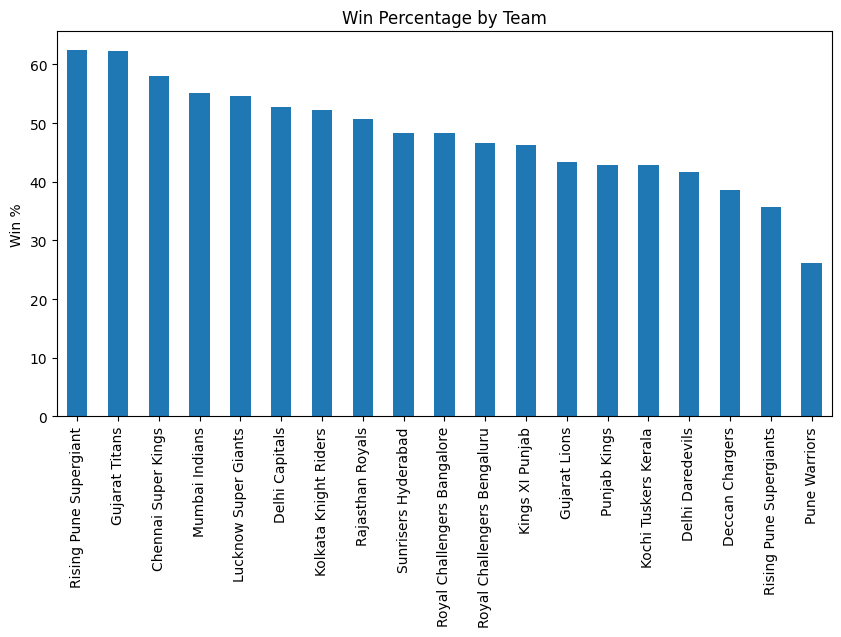

In [53]:
# Win Percentage
matches_played = ipl_df['team1'].value_counts() + ipl_df['team2'].value_counts()
matches_won = ipl_df['winner'].value_counts()
win_percentage = (matches_won / matches_played) * 100
win_percentage.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Win Percentage by Team")
plt.ylabel("Win %")
plt.show()

In [ ]:
# Insight:
# High win percentage teams show consistency rather than just high participation,
# indicating strong team balance and strategy

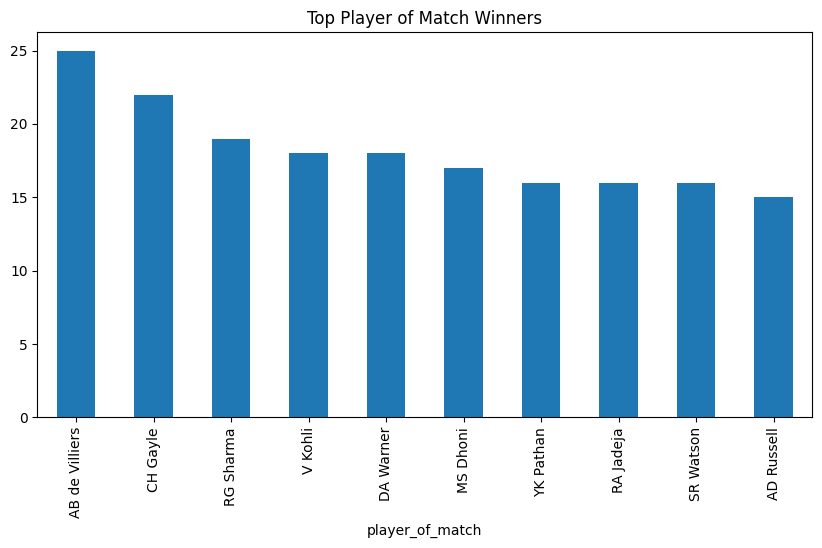

In [37]:
# players performance 
top_players = ipl_df['player_of_match'].value_counts().head(10)

top_players.plot(kind='bar', figsize=(10,5))
plt.title("Top Player of Match Winners")
plt.show()

In [38]:
# Insight:
# A small group of players consistently influence match outcomes,
# showing the importance of key performers.

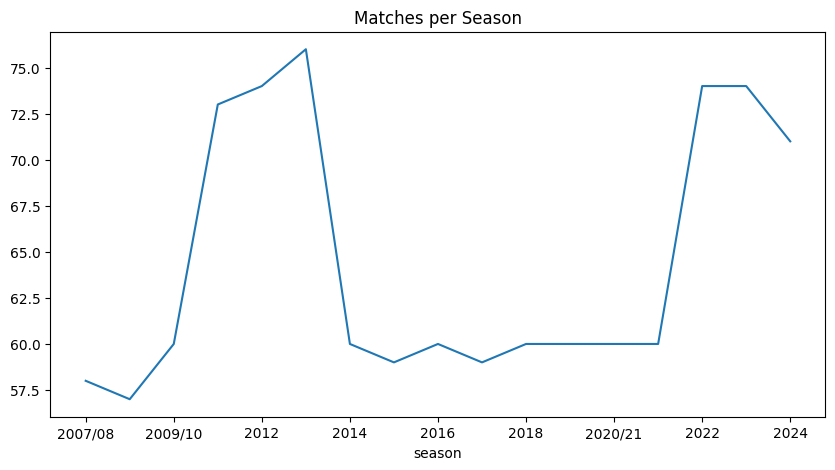

In [43]:
ipl_df['season'].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Matches per Season")
plt.show()

In [ ]:
# Insight:
# Number of matches increased over time, reflecting IPL expansion and popularity growth.

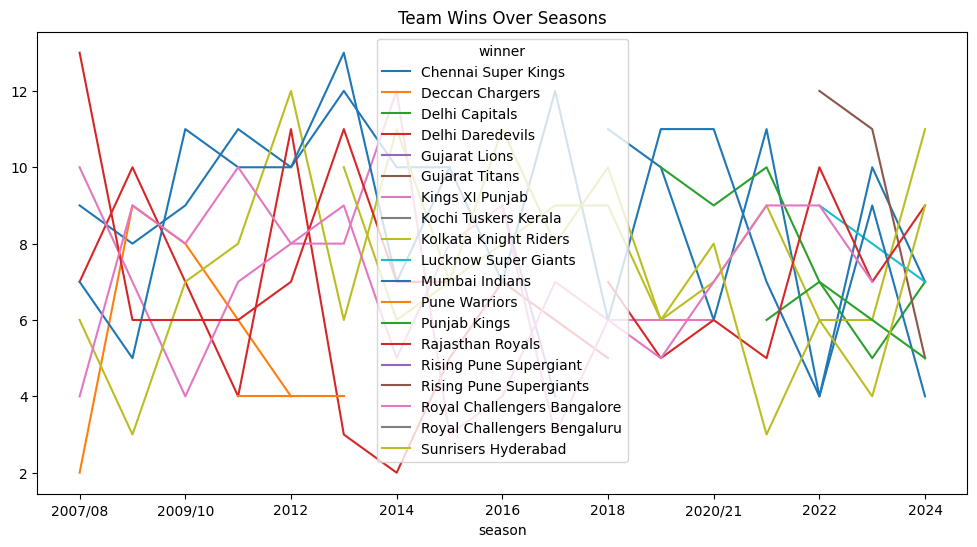

In [45]:
ipl_df.groupby(['season','winner']).size().unstack().plot(figsize=(12,6))
plt.title("Team Wins Over Seasons")
plt.show()

In [ ]:
# Insight:
# Some teams maintain consistent performance across seasons,
# while others fluctuate, indicating stability differences.

In [49]:
close_matches = ipl_df[ipl_df['result_margin'] < 10]
print("Close Matches:", len(close_matches)) # Insight:
# Some matches are highly one-sided, indicating dominance by certain teams.

Close Matches: 666


In [ ]:
# Final Conclusion:

# - Toss has limited overall impact on match results
# - Chasing is a dominant and effective strategy
# - Certain teams consistently outperform others
# - Venue and pitch conditions influence outcomes
# - Key players play a major role in winning matches
# - IPL success depends on strategy, team balance, and performance consistency